# 🧹 Étape 2 — Data Cleaning
## Système de Prédiction des Fraudes — Assurance Automobile
**Auteur :** BENKHOUD Mohamed Bayrem  
**Encadrant :** Mr Khemaies Abdallah  
---

### Objectif de cette étape
Nettoyer le dataset brut afin d'obtenir des données fiables, cohérentes et prêtes pour l'analyse exploratoire (EDA) et la modélisation.

**Plan :**
1. Import des bibliothèques
2. Chargement du dataset
3. Exploration rapide (aperçu avant nettoyage)
4. Suppression des colonnes inutiles
5. Détection et traitement des valeurs manquantes
6. Détection et traitement des valeurs aberrantes (`?`)
7. Suppression des doublons
8. Conversion des types (dates)
9. Standardisation des valeurs catégorielles
10. Résumé final et export

---
## 1. Import des bibliothèques

In [2]:
# --- Bibliothèques de base ---
import pandas as pd          # Manipulation des données tabulaires
import numpy as np           # Calculs numériques

# --- Visualisation ---
import matplotlib.pyplot as plt   # Graphiques de base
import seaborn as sns             # Graphiques statistiques avancés

# --- Affichage Colab ---
from IPython.display import display  # Affichage propre des DataFrames

# --- Options d'affichage pandas ---
pd.set_option('display.max_columns', None)   # Afficher toutes les colonnes
pd.set_option('display.max_rows', 50)        # Limiter les lignes affichées
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 décimales

print('✅ Bibliothèques importées avec succès')

✅ Bibliothèques importées avec succès


---
## 2. Chargement du dataset
Upload manuel depuis Google Colab → utilise le bouton ci-dessous ou la cellule d'upload.

In [3]:
# Chargement du fichier CSV depuis ton ordinateur
# Option 1 : Si le fichier est dans le même répertoire que ce notebook
# Option 2 : Utiliser une boîte de dialogue pour sélectionner le fichier

print('📂 Utilise l\'une des options ci-dessous pour charger le fichier...')
print('   Option 1 : Le fichier insurance_claims.csv est dans le même dossier')
print('   Option 2 : Spécifie le chemin complet du fichier')

# Décommente la ligne correspondant à ton cas :
# file_path = 'insurance_claims.csv'  # Option 1 : même dossier
# file_path = r'C:\Users\bayre\OneDrive\Bureau\projet ML\insurance_claims.csv'  # Option 2 : chemin complet

📂 Utilise l'une des options ci-dessous pour charger le fichier...
   Option 1 : Le fichier insurance_claims.csv est dans le même dossier
   Option 2 : Spécifie le chemin complet du fichier


In [4]:
# Chargement du CSV dans un DataFrame pandas
# On sauvegarde également une copie RAW pour comparaison finale

import os

# Spécifiez le chemin du fichier
file_path = r'C:\Users\bayre\OneDrive\Bureau\projet ML\data\insurance_claims.csv'

# Vérification que le fichier existe
if not os.path.exists(file_path):
	print(f'❌ Fichier non trouvé : {file_path}')
	print(f'   Fichiers disponibles dans le répertoire :')
	directory = os.path.dirname(file_path)
	if os.path.exists(directory):
		print(f'   {os.listdir(directory)}')
	else:
		print(f'   ⚠️  Le répertoire n\'existe pas')
else:
	df = pd.read_csv(file_path)
	df_raw = df.copy()  # Copie du dataset original (jamais modifiée)

	print(f'✅ Dataset chargé avec succès')
	print(f'   → Lignes    : {df.shape[0]}')
	print(f'   → Colonnes  : {df.shape[1]}')

✅ Dataset chargé avec succès
   → Lignes    : 1000
   → Colonnes  : 40


---
## 3. Exploration rapide — aperçu AVANT nettoyage
On observe la structure brute du dataset pour identifier les problèmes.

In [7]:
# Affichage des 5 premières lignes
print('=== 5 premières lignes ===')
if 'df' in locals():
	display(df.head())
else:
	print('⚠️  Erreur : df non défini. Exécutez d\'abord les cellules de chargement des données.')

=== 5 premières lignes ===


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [12]:
# Informations générales : types de données, valeurs non-nulles
print('=== Informations générales ===')
df.info()

=== Informations générales ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   o

In [13]:
# Statistiques descriptives des colonnes numériques
print('=== Statistiques descriptives ===')
display(df.describe())

=== Statistiques descriptives ===


,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,0.00
mean,203.95,38.95,546238.65,1136.00,1256.41,1101000.00,501214.49,25126.10,-26793.70,11.64,1.84,0.99,1.49,52761.94,7433.42,7399.57,37928.95,2005.10,NaN
std,115.11,9.14,257063.01,611.86,244.17,2297406.60,71701.61,27872.19,28104.10,6.95,1.02,0.82,1.11,26401.53,4880.95,4824.73,18886.25,6.02,NaN
min,0.00,19.00,100804.00,500.00,433.33,-1000000.00,430104.00,0.00,-111100.00,0.00,1.00,0.00,0.00,100.00,0.00,0.00,70.00,1995.00,NaN
25%,115.75,32.00,335980.25,500.00,1089.61,0.00,448404.50,0.00,-51500.00,6.00,1.00,0.00,1.00,41812.50,4295.00,4445.00,30292.50,2000.00,NaN
50%,199.50,38.00,533135.00,1000.00,1257.20,0.00,466445.50,0.00,-23250.00,12.00,1.00,1.00,1.00,58055.00,6775.00,6750.00,42100.00,2005.00,NaN
75%,276.25,44.00,759099.75,2000.00,1415.70,0.00,603251.00,51025.00,0.00,17.00,3.00,2.00,2.00,70592.50,11305.00,10885.00,50822.50,2010.00,NaN
max,479.00,64.00,999435.00,2000.00,2047.59,10000000.00,620962.00,100500.00,0.00,23.00,4.00,2.00,3.00,114920.00,21450.00,23670.00,79560.00,2015.00,NaN


In [14]:
# Distribution de la variable cible (fraude ou non)
print('=== Distribution de fraud_reported ===')
print(df['fraud_reported'].value_counts())
print(f"\nTaux de fraude : {df['fraud_reported'].value_counts(normalize=True)['Y']*100:.1f}%")

=== Distribution de fraud_reported ===
fraud_reported
N    753
Y    247
Name: count, dtype: int64

Taux de fraude : 24.7%


---
## 4. Suppression des colonnes inutiles
Certaines colonnes sont des identifiants uniques ou des données trop spécifiques  
qui n'apportent aucune valeur prédictive au modèle.

In [15]:
# Colonnes à supprimer et raison :
# - policy_number     : identifiant unique, aucune valeur prédictive
# - incident_location : adresse trop spécifique, impossible à généraliser
# - insured_zip       : code postal trop précis (on garde policy_state pour la région)
# - _c39              : colonne vide parasite souvent présente dans ce dataset Kaggle

cols_to_drop = ['policy_number', 'incident_location', 'insured_zip']

# On vérifie que la colonne _c39 existe avant de la supprimer
if '_c39' in df.columns:
    cols_to_drop.append('_c39')
    print('⚠️  Colonne parasite _c39 détectée et ajoutée à la liste de suppression')

# Suppression effective
df.drop(columns=cols_to_drop, inplace=True)

print(f'✅ {len(cols_to_drop)} colonnes supprimées : {cols_to_drop}')
print(f'   → Colonnes restantes : {df.shape[1]}')

⚠️  Colonne parasite _c39 détectée et ajoutée à la liste de suppression
✅ 4 colonnes supprimées : ['policy_number', 'incident_location', 'insured_zip', '_c39']
   → Colonnes restantes : 36


---
## 5. Détection et traitement des valeurs manquantes
On cherche les `NaN` classiques que pandas détecte automatiquement.

In [8]:
# Calcul du nombre et pourcentage de valeurs manquantes par colonne
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Valeurs manquantes' : missing_count,
    'Pourcentage (%)'    : missing_pct.round(2)
}).sort_values('Valeurs manquantes', ascending=False)

# Affichage uniquement des colonnes ayant des valeurs manquantes
missing_df_filtered = missing_df[missing_df['Valeurs manquantes'] > 0]

if missing_df_filtered.empty:
    print('✅ Aucune valeur NaN détectée dans le dataset')
else:
    print(f'⚠️  {len(missing_df_filtered)} colonnes avec des NaN détectées :')
    display(missing_df_filtered)

⚠️  2 colonnes avec des NaN détectées :


,Valeurs manquantes,Pourcentage (%)
_c39,1000,100.00
authorities_contacted,91,9.10


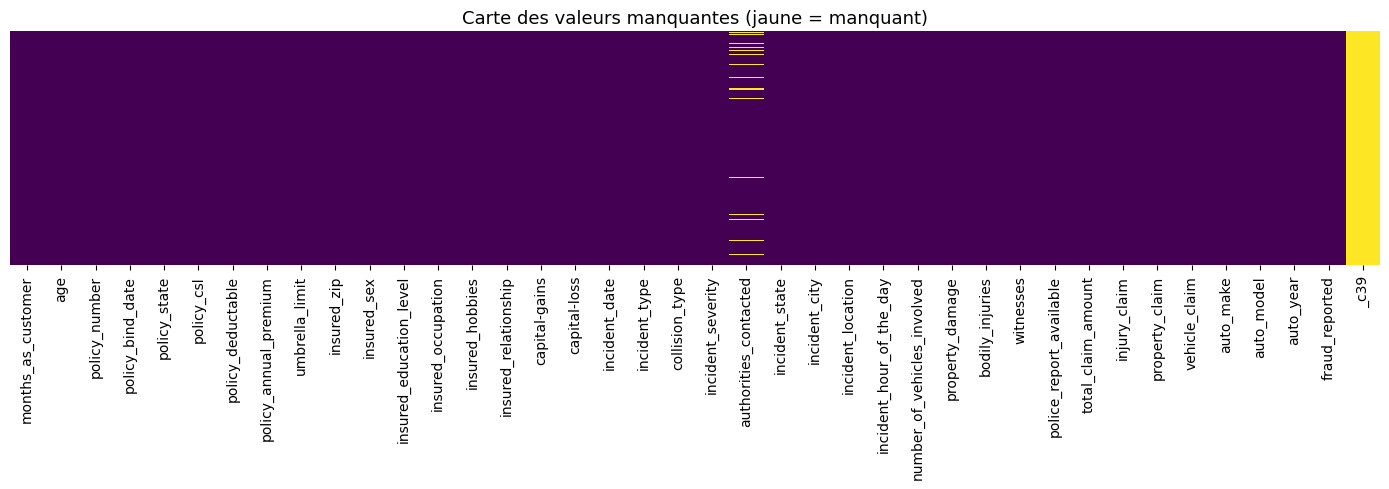

In [9]:
# Visualisation de la carte des valeurs manquantes
plt.figure(figsize=(14, 5))
sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis'
)
plt.title('Carte des valeurs manquantes (jaune = manquant)', fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
# Traitement des valeurs manquantes selon le type de colonne
# Stratégie :
#   - Colonne numérique  → remplacement par la MÉDIANE (robuste aux outliers)
#   - Colonne catégorielle → remplacement par le MODE (valeur la plus fréquente)

for col in df.columns:
    if df[col].isnull().sum() > 0:  # Seulement si la colonne a des NaN
        if df[col].dtype in ['float64', 'int64']:
            mediane = df[col].median()
            df[col].fillna(mediane, inplace=True)
            print(f'   [Numérique]     {col:35s} → rempli par médiane = {mediane:.2f}')
        else:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f'   [Catégorielle]  {col:35s} → rempli par mode = "{mode_val}"')

print(f'\n✅ Valeurs manquantes traitées — NaN restants : {df.isnull().sum().sum()}')

   [Catégorielle]  authorities_contacted               → rempli par mode = "Police"

✅ Valeurs manquantes traitées — NaN restants : 0


C:\Users\bayre\AppData\Local\Temp\ipykernel_24952\2804540169.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


---
## 6. Détection et traitement des valeurs `?`
Ce dataset Kaggle encode certaines valeurs manquantes avec le caractère `?`  
au lieu de `NaN`. Pandas ne les détecte pas automatiquement → traitement manuel.

In [19]:
# Détection des '?' dans les colonnes de type object (texte)
print('=== Colonnes contenant des "?" ===')

cols_with_qmark = []
for col in df.select_dtypes(include='object').columns:
    count = (df[col] == '?').sum()
    if count > 0:
        cols_with_qmark.append(col)
        pct = count / len(df) * 100
        print(f'   ⚠️  {col:40s} → {count} valeurs "?" ({pct:.1f}%)')

if not cols_with_qmark:
    print('   ✅ Aucun "?" détecté dans le dataset')

=== Colonnes contenant des "?" ===
   ⚠️  collision_type                           → 178 valeurs "?" (17.8%)
   ⚠️  property_damage                          → 360 valeurs "?" (36.0%)
   ⚠️  police_report_available                  → 343 valeurs "?" (34.3%)


In [20]:
# Remplacement des '?' par NaN, puis traitement par le MODE
# Pourquoi le MODE ? Ces colonnes sont catégorielles,
# donc on impute la valeur la plus représentative.

for col in cols_with_qmark:
    df[col].replace('?', np.nan, inplace=True)   # '?' → NaN
    mode_val = df[col].mode()[0]                  # Calcul du mode
    df[col].fillna(mode_val, inplace=True)        # NaN → mode
    print(f'   ✅ {col:40s} → remplacé par "{mode_val}"')

print(f'\n✅ Traitement des "?" terminé')

   ✅ collision_type                           → remplacé par "Rear Collision"
   ✅ property_damage                          → remplacé par "NO"
   ✅ police_report_available                  → remplacé par "NO"

✅ Traitement des "?" terminé


C:\Users\bayre\AppData\Local\Temp\ipykernel_24952\282444987.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].replace('?', np.nan, inplace=True)   # '?' → NaN
C:\Users\bayre\AppData\Local\Temp\ipykernel_24952\282444987.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

---
## 7. Suppression des doublons
Des lignes identiques peuvent biaiser l'entraînement du modèle.

In [21]:
# Détection des doublons
nb_doublons = df.duplicated().sum()
print(f'Nombre de lignes dupliquées détectées : {nb_doublons}')

if nb_doublons > 0:
    print('\nAperçu des doublons :')
    display(df[df.duplicated()].head())
    
    # Suppression des doublons (on garde la première occurrence)
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)  # Réinitialise l'index
    print(f'\n✅ Doublons supprimés — Lignes restantes : {len(df)}')
else:
    print('✅ Aucun doublon détecté')

Nombre de lignes dupliquées détectées : 0
✅ Aucun doublon détecté


---
## 8. Conversion des types — colonnes dates
Les dates sont chargées comme des chaînes de caractères (`object`).  
On les convertit en `datetime` pour pouvoir calculer des durées (feature engineering).

In [22]:
# Conversion de policy_bind_date et incident_date en datetime
df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'], errors='coerce')
df['incident_date']    = pd.to_datetime(df['incident_date'],    errors='coerce')

# errors='coerce' : si la conversion échoue pour une valeur, elle devient NaN
# (plutôt que de faire planter tout le programme)

print('Types après conversion :')
print(f'   policy_bind_date : {df["policy_bind_date"].dtype}')
print(f'   incident_date    : {df["incident_date"].dtype}')

# Vérification qu'il n'y a pas eu d'erreurs de conversion
print(f'\nNaN introduits par conversion :')
print(f'   policy_bind_date : {df["policy_bind_date"].isnull().sum()}')
print(f'   incident_date    : {df["incident_date"].isnull().sum()}')

print('\n✅ Conversion des dates terminée')

Types après conversion :
   policy_bind_date : datetime64[ns]
   incident_date    : datetime64[ns]

NaN introduits par conversion :
   policy_bind_date : 0
   incident_date    : 0

✅ Conversion des dates terminée


In [23]:
# Aperçu de la plage temporelle du dataset
print(f'Période couverte par les incidents :')
print(f'   Du  : {df["incident_date"].min().date()}')
print(f'   Au  : {df["incident_date"].max().date()}')

print(f'\nPériode de souscription des polices :')
print(f'   Du  : {df["policy_bind_date"].min().date()}')
print(f'   Au  : {df["policy_bind_date"].max().date()}')

Période couverte par les incidents :
   Du  : 2015-01-01
   Au  : 2015-03-01

Période de souscription des polices :
   Du  : 1990-01-08
   Au  : 2015-02-22


---
## 9. Standardisation des valeurs catégorielles
On s'assure que les chaînes de caractères sont uniformes :  
pas de majuscules/minuscules mixtes, pas d'espaces parasites.

In [24]:
# Pour chaque colonne de type texte (object), on applique :
#   - .str.strip()  : supprime les espaces en début/fin
#   - .str.upper()  : met tout en majuscules pour uniformiser

# Exception : on ne touche PAS aux colonnes datetime déjà converties
cols_object = df.select_dtypes(include='object').columns.tolist()

for col in cols_object:
    df[col] = df[col].str.strip().str.upper()

print(f'✅ Standardisation appliquée sur {len(cols_object)} colonnes catégorielles')

# Vérification sur la variable cible
print(f'\nValeurs de fraud_reported après standardisation :')
print(df['fraud_reported'].value_counts())

✅ Standardisation appliquée sur 18 colonnes catégorielles

Valeurs de fraud_reported après standardisation :
fraud_reported
N    753
Y    247
Name: count, dtype: int64


In [25]:
# Vérification des valeurs uniques des colonnes catégorielles importantes
# pour détecter d'éventuelles incohérences résiduelles

cols_to_check = [
    'fraud_reported', 'incident_type', 'incident_severity',
    'police_report_available', 'property_damage', 'insured_sex'
]

print('=== Valeurs uniques des colonnes clés ===')
for col in cols_to_check:
    if col in df.columns:
        vals = df[col].unique()
        print(f'   {col:35s} → {vals}')

=== Valeurs uniques des colonnes clés ===
   fraud_reported                      → ['Y' 'N']
   incident_type                       → ['SINGLE VEHICLE COLLISION' 'VEHICLE THEFT' 'MULTI-VEHICLE COLLISION'
 'PARKED CAR']
   incident_severity                   → ['MAJOR DAMAGE' 'MINOR DAMAGE' 'TOTAL LOSS' 'TRIVIAL DAMAGE']
   police_report_available             → ['YES' 'NO']
   property_damage                     → ['YES' 'NO']
   insured_sex                         → ['MALE' 'FEMALE']


---
## 10. Résumé final et export du dataset nettoyé

In [26]:
# ============================================================
#  TABLEAU COMPARATIF : AVANT vs APRÈS nettoyage
# ============================================================

print('=' * 55)
print('        RÉSUMÉ DU NETTOYAGE — AVANT vs APRÈS')
print('=' * 55)
print(f"  {'Métrique':<30} {'AVANT':>10} {'APRÈS':>10}")
print('-' * 55)
print(f"  {'Lignes':<30} {df_raw.shape[0]:>10} {df.shape[0]:>10}")
print(f"  {'Colonnes':<30} {df_raw.shape[1]:>10} {df.shape[1]:>10}")
print(f"  {'Valeurs NaN':<30} {df_raw.isnull().sum().sum():>10} {df.isnull().sum().sum():>10}")
print(f"  {'Doublons':<30} {df_raw.duplicated().sum():>10} {df.duplicated().sum():>10}")
print('=' * 55)
print('\n✅ Dataset nettoyé et prêt pour l\'EDA (Étape 3)')

        RÉSUMÉ DU NETTOYAGE — AVANT vs APRÈS
  Métrique                            AVANT      APRÈS
-------------------------------------------------------
  Lignes                               1000       1000
  Colonnes                               40         36
  Valeurs NaN                          1091          0
  Doublons                                0          0

✅ Dataset nettoyé et prêt pour l'EDA (Étape 3)


In [27]:
# Aperçu des types de données finaux
print('=== Types de données finaux ===')
dtype_df = pd.DataFrame({
    'Colonne' : df.dtypes.index,
    'Type'    : df.dtypes.values,
    'Non-null': df.count().values,
    'Unique'  : [df[c].nunique() for c in df.columns]
})
display(dtype_df)

=== Types de données finaux ===


,Colonne,Type,Non-null,Unique
0,months_as_customer,int64,1000,391
1,age,int64,1000,46
2,policy_bind_date,datetime64[ns],1000,951
3,policy_state,object,1000,3
4,policy_csl,object,1000,3
5,policy_deductable,int64,1000,3
6,policy_annual_premium,float64,1000,991
7,umbrella_limit,int64,1000,11
8,insured_sex,object,1000,2
9,insured_education_level,object,1000,7


In [28]:
# Export du dataset nettoyé en CSV
# Ce fichier sera réutilisé dans l'Étape 3 (EDA) et les suivantes
output_path = 'insurance_claims_cleaned.csv'
df.to_csv(output_path, index=False)

print(f'✅ Dataset nettoyé exporté → {output_path}')
print(f'   Taille : {df.shape[0]} lignes × {df.shape[1]} colonnes')



✅ Dataset nettoyé exporté → insurance_claims_cleaned.csv
   Taille : 1000 lignes × 36 colonnes
